In [1]:
# Import Library yang dibutuhkan 
import wfdb
import matplotlib.pyplot as plt
import numpy as np

## Memuat dan Memvisualisasikan Sinyal ECG
Tujuan: Memahami struktur data dan pola dasar dalam sinyal ECG.

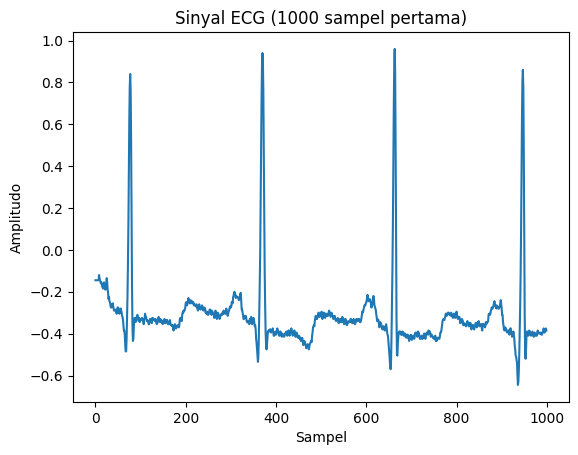

In [2]:
# Memuat dataset MIT-BIH (contoh file .dat)
record = wfdb.rdsamp('./wfdb-sample-data/100') # Gunakan rekaman yang diunduh atau dataset bawaan
signal = record[0][:, 0] # Ekstraksi satu saluran sinyal ECG
fs = record[1]['fs'] # Frekuensi sampling

# Visualisasi sinyal ECG
plt.plot(signal[:1000]) # Plot 1000 sampel pertama
plt.title('Sinyal ECG (1000 sampel pertama)')
plt.xlabel('Sampel')
plt.ylabel('Amplitudo')
plt.show()

## Filtering Sinyal ECG
Tujuan: Menghilangkan noise dan interferensi baseline dari sinyal ECG.

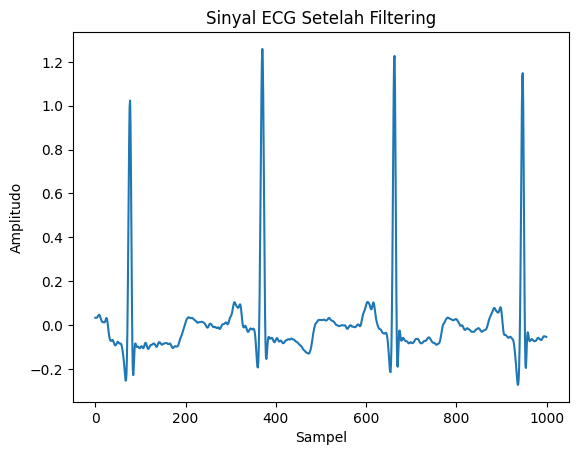

In [3]:
from scipy.signal import butter, filtfilt

# Fungsi untuk menerapkan filter Butterworth
def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def bandpass_filter(data, lowcut, highcut, fs, order=4):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = filtfilt(b, a, data)
    return y

# Terapkan filter bandpass
filtered_signal = bandpass_filter(signal, 0.5, 45.0, fs)

# Visualisasi hasil filtering
plt.plot(filtered_signal[:1000])
plt.title('Sinyal ECG Setelah Filtering')
plt.xlabel('Sampel')
plt.ylabel('Amplitudo')
plt.show()



## Deteksi Kompleks QRS

Tujuan: Mendemonstrasikan algoritma dasar untuk deteksi kompleks QRS pada sinyal ECG.

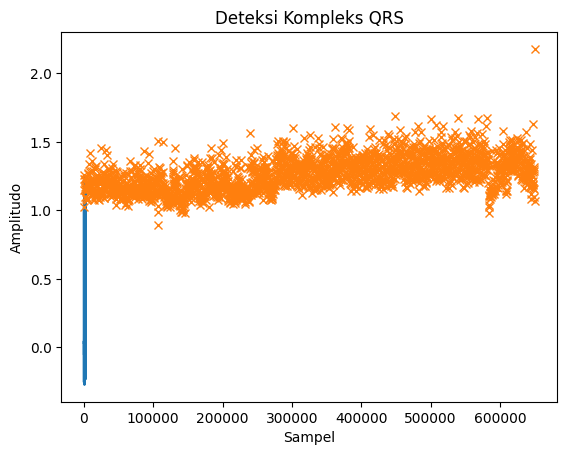

In [4]:
from scipy.signal import find_peaks

# Deteksi puncak sebagai kompleks QRS
peaks, _ = find_peaks(filtered_signal, distance=fs*0.6, height=0.5)

# Visualisasi deteksi kompleks QRS
plt.plot(filtered_signal[:3000])
plt.plot(peaks, filtered_signal[peaks], "x")
plt.title('Deteksi Kompleks QRS')
plt.xlabel('Sampel')
plt.ylabel('Amplitudo')
plt.show()

## Ekstraksi Fitur Sederhana (Interval RR dan Heart Rate Variability - HRV)
Tujuan: Menghitung interval RR untuk analisis lebih lanjut.

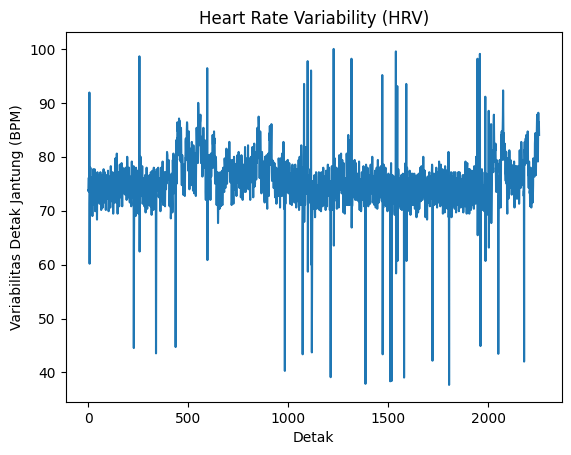

In [5]:
# Menghitung interval RR (dalam detik)
rr_intervals = np.diff(peaks) / fs  # Konversi sampel ke detik
hrv = 60 / rr_intervals  # Hitung HRV

# Visualisasi HRV
plt.plot(hrv)
plt.title('Heart Rate Variability (HRV)')
plt.xlabel('Detak')
plt.ylabel('Variabilitas Detak Jantung (BPM)')
plt.show()

## Implementasi Pemodelan Sederhana

Tujuan: Memperkenalkan analisis lanjut dengan model sederhana untuk mendeteksi abnormalitas seperti aritmia.

Rata-rata HRV: 75.37184549051693 BPM
Standar deviasi HRV: 5.076505661884191 BPM


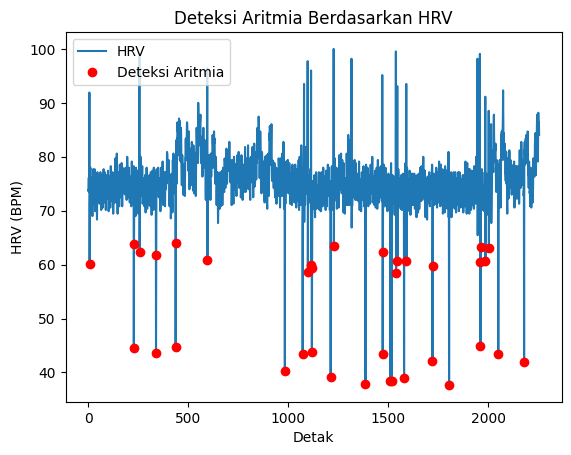

In [6]:
# Menghitung rata-rata dan varians HRV sebagai deteksi dasar abnormalitas
mean_hrv = np.mean(hrv)
std_hrv = np.std(hrv)
print("Rata-rata HRV:", mean_hrv, "BPM")
print("Standar deviasi HRV:", std_hrv, "BPM")

# Threshold sederhana untuk mendeteksi aritmia (contoh)
threshold = mean_hrv - 2 * std_hrv
aritmia = hrv < threshold

plt.plot(hrv, label='HRV')
plt.plot(np.where(aritmia)[0], hrv[aritmia], "ro", label='Deteksi Aritmia')
plt.title('Deteksi Aritmia Berdasarkan HRV')
plt.xlabel('Detak')
plt.ylabel('HRV (BPM)')
plt.legend()
plt.show()